# Nepal Flood & Weather: XGBoost vs Linear Regression
XGBoost vs Linear Regression: river discharge from weather, Nepal Flood & Weather Dataset 2023-2026

Findings about the raw CSV that this script handles:
  * Dates are day-first (dd-mm-yyyy).
  * All 2023 rows (3,650) have weather columns shifted by one position relative
    to the header, e.g. 'temperature_mean_c' holds soil moisture. Fixed below.
  * latitude / longitude / elevation / DHM Station / river / basin are constants
    per station, so one-hot 'location' replaces them.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PATH = "/Users/arijeetbhadra/Downloads/archive/nepal_flood_weather_dataset_kaggle_2023_2026.csv"
TEST_START = "2025-09-01"   # test = final 12 months (includes a full monsoon)

In [22]:
# ---------------------------------------------------------------- load + fix
df = pd.read_csv(PATH)
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

SOIL, RAIN, TEMP, DEW, PH = ("soil_moisture_0_100cm_m3m3", "rain_mm",
                             "temperature_mean_c", "dew_point_mean_c",
                             "precipitation_hours")
m = df["date"].dt.year == 2023            # shifted block
fixed = df.loc[m, [SOIL, RAIN, TEMP, DEW, PH]].copy()
df.loc[m, RAIN] = fixed[SOIL].values      # true rain       was in 'soil' column
df.loc[m, PH] = fixed[RAIN].values        # true precip hrs was in 'rain' column
df.loc[m, SOIL] = fixed[TEMP].values      # true soil       was in 'temp' column
df.loc[m, TEMP] = fixed[DEW].values       # true temp       was in 'dew' column
df.loc[m, DEW] = fixed[PH].values         # true dew point  was in 'precip_hours'
assert (df[DEW] <= df[TEMP] + 0.05).all() and df[SOIL].max() < 1
raw = df.copy()   # cleaned data; the feature cell below always starts from this

In [23]:
# ----------------------------------------------------------------- features
df = raw.sort_values(["location", "date"]).reset_index(drop=True)
g = df.groupby("location")
for w in (3, 7, 14, 30):                  # antecedent rainfall (past-only)
    df[f"precip_{w}d"] = g["precipitation_mm"].transform(
        lambda s: s.rolling(w, min_periods=1).sum())
df["precip_lag1"] = g["precipitation_mm"].shift(1)
df["soil_lag1"] = g[SOIL].shift(1)
df["doy_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofyear / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofyear / 365.25)
df["log_q"] = np.log1p(df["river_discharge_m3s"])
df["log_q_lag1"] = g["log_q"].shift(1)    # yesterday's discharge (Model B only)
df = df.dropna().reset_index(drop=True)

weather = ["precipitation_mm", RAIN, PH, SOIL, TEMP, DEW,
           "relative_humidity_mean_pct", "wind_speed_max_kmh",
           "wind_gusts_max_kmh", "precip_lag1", "precip_3d", "precip_7d",
           "precip_14d", "precip_30d", "soil_lag1", "doy_sin", "doy_cos"]
FEATURES = {
    "A: weather + station": weather,
    "B: A + yesterday's discharge": weather + ["log_q_lag1"],
}

train, test = df[df["date"] < TEST_START], df[df["date"] >= TEST_START]
print(f"train {len(train)} rows | test {len(test)} rows\n")

train 9730 rows | test 3650 rows



In [24]:
# ------------------------------------------------------------ fit + score
# pip install xgboost
from xgboost import XGBRegressor

# Guard: this section needs the feature-engineering section above to have run
_need = {c for cols in FEATURES.values() for c in cols}
_missing = sorted(c for c in _need if c not in df.columns)
if _missing:
    raise RuntimeError(f"Missing engineered columns {_missing}. Run the cells in order "
                       "(Kernel > Restart & Run All) instead of re-running only this cell.")

# Safe to re-run: drop any station dummies from a previous run first
df = df.drop(columns=[c for c in df.columns if c.startswith("loc_")])
df = pd.concat([df, pd.get_dummies(df["location"], prefix="loc", dtype=float)], axis=1)
loc_cols = [c for c in df.columns if c.startswith("loc_")]
train, test = df[df["date"] < TEST_START], df[df["date"] >= TEST_START]

def make_xgb():
    return XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                        reg_lambda=1.0, random_state=42, n_jobs=-1)

def scores(y_log, p_log, y):
    p = np.clip(np.expm1(p_log), 0, None)
    return dict(R2_log=r2_score(y_log, p_log), R2=r2_score(y, p),
                MAE=mean_absolute_error(y, p),
                RMSE=float(np.sqrt(mean_squared_error(y, p)))), p

rows, preds, models = {}, {}, {}
for name, num in FEATURES.items():
    cols = num + loc_cols
    # linear baseline
    lin = Pipeline([("sc", ColumnTransformer([("n", StandardScaler(), num)], remainder="passthrough")),
                    ("lr", LinearRegression())]).fit(train[cols], train["log_q"])
    rows[f"Linear | {name}"], _ = scores(test["log_q"], lin.predict(test[cols]), test["river_discharge_m3s"])
    # XGBoost
    xgb = make_xgb().fit(train[cols], train["log_q"])
    rows[f"XGBoost | {name}"], preds[name] = scores(test["log_q"], xgb.predict(test[cols]),
                                                    test["river_discharge_m3s"])
    models[name] = (xgb, cols)

print(pd.DataFrame(rows).T.round(3).to_string())

# per-station R2 (log scale), XGBoost Model A
best = "A: weather + station"
tmp = test.assign(pred_log=np.log1p(preds[best]))
print("\nPer-station R2 (log scale), XGBoost Model A:")
print(tmp.groupby("location").apply(
    lambda d: r2_score(d["log_q"], d["pred_log"]), include_groups=False).round(3))

# feature importance (gain)
xgb, cols = models[best]
imp = pd.Series(xgb.get_booster().get_score(importance_type="gain")).sort_values(ascending=False)
print("\nTop 12 features by gain (XGBoost Model A):")
print(imp.head(12).round(2))

                                        R2_log     R2     MAE    RMSE
Linear | A: weather + station            0.890  0.336  12.209  53.169
XGBoost | A: weather + station           0.958  0.841   6.079  25.981
Linear | B: A + yesterday's discharge    0.992  0.956   2.166  13.641
XGBoost | B: A + yesterday's discharge   0.993  0.947   2.555  14.959

Per-station R2 (log scale), XGBoost Model A:
location
Bahrabise              0.944
Belsot                 0.832
Bhada Bridge           0.484
Chameliya/Nayalbadi    0.930
Chatara                0.812
Chisapani              0.903
Devghat                0.811
Khokana                0.862
Kusum                  0.847
Rasuwagadhi            0.873
dtype: float64

Top 12 features by gain (XGBoost Model A):
loc_Belsot                    201.35
loc_Kusum                     187.54
loc_Chameliya/Nayalbadi       157.94
loc_Bhada Bridge               26.74
loc_Chisapani                  25.58
loc_Bahrabise                  25.03
precip_30d              

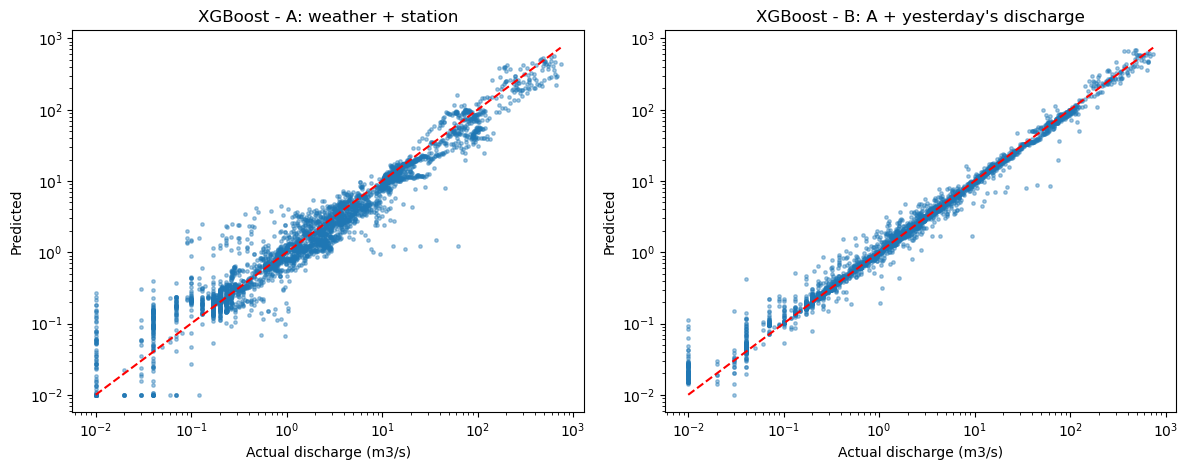

In [25]:
# -------------------------------------------------------------------- plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for a, name in zip(ax, FEATURES):
    p = preds[name]
    a.scatter(test["river_discharge_m3s"] + 0.01, p + 0.01, s=6, alpha=.4)
    lim = [0.01, max(test["river_discharge_m3s"].max(), p.max())]
    a.plot(lim, lim, "r--")
    a.set(xscale="log", yscale="log", xlabel="Actual discharge (m3/s)",
          ylabel="Predicted", title=f"XGBoost - {name}")
plt.tight_layout()
plt.savefig("xgboost_results.png", dpi=150)
plt.show()